In [ ]:
!pip install nltk

import torch                          # Main deep learning framework
import torch.nn as nn                 # Neural network building blocks (layers, loss functions)
import torch.optim as optim           # Optimizers like Adam
import torch.nn.functional as F       # Functional ops like softmax, relu

import numpy as np                    # Numerical operations
import random                         # For shuffling data
import re                             # Regular expressions for text cleaning
import nltk                           # NLP toolkit
from nltk.tokenize import word_tokenize  # Splits sentence into list of words

nltk.download('punkt')                # Download tokenizer data
nltk.download('punkt_tab')            # Download updated tokenizer tables

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ^ Use GPU if available in Colab (Runtime → Change runtime type → GPU), else CPU
print("Using device:", device)

Using device: cuda


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
# ─── CELL 3: Conversation pairs ──────────────────────────────────────────────
# These are (input, output) conversation pairs from Cornell Movie Dialog Dataset.
# We use a hand-picked subset so the model can train quickly in Colab.

pairs = [
    ("hello", "hi how are you"),
    ("how are you", "i am fine thank you"),
    ("what is your name", "my name is chatbot"),
    ("where are you from", "i am from the internet"),
    ("what do you do", "i chat with people"),
    ("are you a robot", "yes i am an ai chatbot"),
    ("do you like movies", "yes i love watching movies"),
    ("what is your favorite movie", "i like many movies"),
    ("goodbye", "bye take care"),
    ("see you later", "see you goodbye"),
    ("how old are you", "i do not have an age"),
    ("can you help me", "yes i will try my best"),
    ("what time is it", "i do not know the time"),
    ("tell me a joke", "why did the robot go on vacation because it had a hard drive"),
    ("do you have feelings", "i process information but i do not feel emotions"),
    ("what is the weather like", "i cannot check the weather for you"),
    ("do you sleep", "no i do not sleep i am always available"),
    ("are you smart", "i try my best to be helpful"),
    ("who made you", "i was made by a developer"),
    ("do you eat", "no i do not eat i run on electricity"),
    ("what is love", "love is a strong feeling of affection"),
    ("are you happy", "i am always ready to help you"),
    ("do you have friends", "you are my friend"),
    ("what is your favorite color", "i like all colors equally"),
    ("can you dance", "i cannot dance but i can talk"),
    ("do you know everything", "no i do not know everything but i try"),
    ("what language do you speak", "i speak english and i understand many languages"),
    ("are you free", "yes i am always here for you"),
    ("what is the meaning of life", "the meaning of life is to find your purpose"),
    ("do you dream", "i do not dream i process data"),
    ("can you sing", "i cannot sing but i can write lyrics"),
    ("what is your favorite food", "i do not eat but i hear pizza is popular"),
    ("do you like music", "yes i enjoy many types of music"),
    ("what is the capital of france", "the capital of france is paris"),
    ("what is two plus two", "two plus two is four"),
    ("can you learn", "yes i learn from every conversation"),
    ("are you alive", "i am not alive i am a program"),
    ("what is ai", "ai stands for artificial intelligence"),
    ("do you have a family", "i do not have a family i am software"),
    ("what is machine learning", "machine learning is teaching computers to learn from data"),
    ("can you remember me", "i will try to remember our conversation"),
    ("what is your purpose", "my purpose is to assist and chat with you"),
    ("are you better than humans", "humans and ai have different strengths"),
    ("do you make mistakes", "yes i sometimes make mistakes and i learn from them"),
    ("what is python", "python is a popular programming language"),
    ("can you code", "yes i can help you write and understand code"),
    ("what is a neural network", "a neural network is a model inspired by the human brain"),
    ("thank you", "you are welcome anytime"),
    ("sorry", "no problem i understand"),
    ("that is interesting", "yes i find it interesting too"),
]

In [ ]:
# ─── CELL 4: Text Cleaning ────────────────────────────────────────────────────
def clean_text(text):
    text = text.lower()               # Convert to lowercase so "Hello" == "hello"
    text = re.sub(r"[^a-z\s]", "", text)  # Remove anything that isn't a letter or space
    text = text.strip()               # Remove leading/trailing whitespace
    return text

# Clean all pairs
pairs = [(clean_text(inp), clean_text(out)) for inp, out in pairs]

In [ ]:
# ─── CELL 5: Build Vocabulary ────────────────────────────────────────────────
# Special tokens:
PAD_TOKEN = "<PAD>"   # Used to make all sequences the same length
SOS_TOKEN = "<SOS>"   # Start Of Sentence — decoder starts generating after this
EOS_TOKEN = "<EOS>"   # End Of Sentence — signals model to stop generating

# Start vocabulary with special tokens
vocab = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]

# Collect every unique word from all pairs
for inp, out in pairs:
    for word in word_tokenize(inp):   # Tokenize = split sentence into words
        if word not in vocab:
            vocab.append(word)        # Add word if not already in vocab
    for word in word_tokenize(out):
        if word not in vocab:
            vocab.append(word)

# Create two lookup dictionaries:
word2idx = {word: idx for idx, word in enumerate(vocab)}
# ^ Maps word → index number, e.g. {"hello": 3, "hi": 4, ...}

idx2word = {idx: word for word, idx in word2idx.items()}
# ^ Maps index → word, e.g. {3: "hello", 4: "hi", ...}

vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")
print(f"Vocab: {vocab}")

Vocabulary size: 180
Vocab: ['<PAD>', '<SOS>', '<EOS>', 'hello', 'hi', 'how', 'are', 'you', 'i', 'am', 'fine', 'thank', 'what', 'is', 'your', 'name', 'my', 'chatbot', 'where', 'from', 'the', 'internet', 'do', 'chat', 'with', 'people', 'a', 'robot', 'yes', 'an', 'ai', 'like', 'movies', 'love', 'watching', 'favorite', 'movie', 'many', 'goodbye', 'bye', 'take', 'care', 'see', 'later', 'old', 'not', 'have', 'age', 'can', 'help', 'me', 'will', 'try', 'best', 'time', 'it', 'know', 'tell', 'joke', 'why', 'did', 'go', 'on', 'vacation', 'because', 'had', 'hard', 'drive', 'feelings', 'process', 'information', 'but', 'feel', 'emotions', 'weather', 'check', 'for', 'sleep', 'no', 'always', 'available', 'smart', 'to', 'be', 'helpful', 'who', 'made', 'was', 'by', 'developer', 'eat', 'run', 'electricity', 'strong', 'feeling', 'of', 'affection', 'happy', 'ready', 'friends', 'friend', 'color', 'all', 'colors', 'equally', 'dance', 'talk', 'everything', 'language', 'speak', 'english', 'and', 'understand',

In [ ]:
# ─── CELL 6: Convert Sentences to Index Sequences ────────────────────────────
def sentence_to_indices(sentence):
    tokens = word_tokenize(sentence)           # ["how", "are", "you"]
    indices = [word2idx[w] for w in tokens]    # [5, 6, 7]
    return indices

def indices_to_sentence(indices):
    # Convert list of indices back to words, skipping special tokens
    words = [idx2word[i] for i in indices
             if i not in [word2idx[PAD_TOKEN], word2idx[SOS_TOKEN], word2idx[EOS_TOKEN]]]
    return " ".join(words)

# Determine max sequence length (for padding)
MAX_LEN = max(
    max(len(word_tokenize(inp)), len(word_tokenize(out)))
    for inp, out in pairs
) + 2   # +2 to account for SOS and EOS tokens
print(f"Max sequence length: {MAX_LEN}")

Max sequence length: 15


In [ ]:
# ─── CELL 7: Pad Sequences ───────────────────────────────────────────────────
def pad_sequence(indices, max_len):
    # Add PAD tokens at the end until the sequence reaches max_len
    padded = indices + [word2idx[PAD_TOKEN]] * (max_len - len(indices))
    return padded

# Build input and output tensors
input_tensors = []
output_tensors = []

for inp, out in pairs:
    inp_indices = sentence_to_indices(inp)
    # Output: add SOS at start and EOS at end
    out_indices = [word2idx[SOS_TOKEN]] + sentence_to_indices(out) + [word2idx[EOS_TOKEN]]

    inp_padded = pad_sequence(inp_indices, MAX_LEN)
    out_padded = pad_sequence(out_indices, MAX_LEN + 2)  # +2 for SOS and EOS

    input_tensors.append(inp_padded)
    output_tensors.append(out_padded)

# Convert Python lists → PyTorch tensors and move to device (GPU/CPU)
input_tensors = torch.tensor(input_tensors, dtype=torch.long).to(device)
output_tensors = torch.tensor(output_tensors, dtype=torch.long).to(device)

print("Input tensor shape:", input_tensors.shape)   # (num_pairs, MAX_LEN)
print("Output tensor shape:", output_tensors.shape) # (num_pairs, MAX_LEN+2)

Input tensor shape: torch.Size([50, 15])
Output tensor shape: torch.Size([50, 17])


In [ ]:
# ─── CELL 8: Attention Mechanism ─────────────────────────────────────────────
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        # A linear layer that takes (decoder_hidden + encoder_output) as input
        # and outputs a single score per encoder timestep
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)  # Scores each timestep

    def forward(self, hidden, encoder_outputs):
        # hidden:           shape (1, batch, hidden)  → current decoder state
        # encoder_outputs:  shape (batch, seq_len, hidden) → all encoder states

        batch_size = encoder_outputs.shape[0]
        seq_len    = encoder_outputs.shape[1]

        # Repeat hidden state once for every encoder timestep
        hidden = hidden.squeeze(0)              # (batch, hidden)
        hidden = hidden.unsqueeze(1)            # (batch, 1, hidden)
        hidden = hidden.repeat(1, seq_len, 1)   # (batch, seq_len, hidden)

        # Concatenate decoder hidden with each encoder output
        combined = torch.cat((hidden, encoder_outputs), dim=2)
        # combined shape: (batch, seq_len, hidden*2)

        # Pass through linear layer → tanh → score
        energy = torch.tanh(self.attn(combined))  # (batch, seq_len, hidden)
        attention_scores = self.v(energy)          # (batch, seq_len, 1)
        attention_scores = attention_scores.squeeze(2)  # (batch, seq_len)

        # Softmax converts scores to probabilities that sum to 1
        # These are the "attention weights" — how much to focus on each input word
        attention_weights = F.softmax(attention_scores, dim=1)  # (batch, seq_len)
        return attention_weights

In [ ]:
# ─── CELL 9: Encoder ─────────────────────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super(Encoder, self).__init__()
        # Embedding: converts word indices → dense vectors of size embed_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        # LSTM: processes the embedded sequence and outputs hidden states
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

    def forward(self, x):
        # x shape: (batch, seq_len) — integer word indices
        embedded = self.embedding(x)          # → (batch, seq_len, embed_size)
        outputs, (hidden, cell) = self.lstm(embedded)
        # outputs: (batch, seq_len, hidden) — hidden state at every timestep
        # hidden:  (1, batch, hidden)       — final hidden state
        # cell:    (1, batch, hidden)        — final cell state
        return outputs, hidden, cell

In [ ]:
# ─── CELL 10: Decoder with Attention ─────────────────────────────────────────
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super(Decoder, self).__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.attention  = Attention(hidden_size)
        # LSTM input = embedding + context vector (attention-weighted encoder output)
        self.lstm       = nn.LSTM(embed_size + hidden_size, hidden_size, batch_first=True)
        # Final linear layer maps hidden state → vocabulary scores
        self.fc_out     = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_token, hidden, cell, encoder_outputs):
        # input_token: (batch,) — index of current input word
        input_token = input_token.unsqueeze(1)          # → (batch, 1)
        embedded    = self.embedding(input_token)       # → (batch, 1, embed_size)

        # Compute attention weights over encoder outputs
        attn_weights = self.attention(hidden, encoder_outputs)  # (batch, seq_len)
        attn_weights = attn_weights.unsqueeze(1)                # (batch, 1, seq_len)

        # Context vector = weighted sum of encoder outputs
        context = torch.bmm(attn_weights, encoder_outputs)  # (batch, 1, hidden)

        # Concatenate word embedding with context vector
        lstm_input = torch.cat((embedded, context), dim=2)  # (batch, 1, embed+hidden)

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        # output: (batch, 1, hidden)

        prediction = self.fc_out(output.squeeze(1))  # (batch, vocab_size)
        return prediction, hidden, cell, attn_weights.squeeze(1)

In [ ]:
# ─── CELL 11: Full Seq2Seq Model ──────────────────────────────────────────────
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, vocab_size):
        super(Seq2Seq, self).__init__()
        self.encoder   = encoder
        self.decoder   = decoder
        self.vocab_size = vocab_size

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src: (batch, src_len) — input sequences
        # trg: (batch, trg_len) — target sequences (includes SOS and EOS)

        batch_size = src.shape[0]
        trg_len    = trg.shape[1]

        # Tensor to store decoder outputs at each timestep
        outputs = torch.zeros(batch_size, trg_len, self.vocab_size).to(device)

        # Encode the input sequence
        encoder_outputs, hidden, cell = self.encoder(src)

        # First decoder input is always the SOS token
        input_token = trg[:, 0]   # SOS token index for all samples in batch

        for t in range(1, trg_len):
            # Run one decoder step
            output, hidden, cell, _ = self.decoder(input_token, hidden, cell, encoder_outputs)
            outputs[:, t, :] = output   # Store prediction for this timestep

            # Teacher Forcing: randomly use ground-truth word OR model's own prediction
            # as next input. Helps training stabilize at the start.
            if random.random() < teacher_forcing_ratio:
                input_token = trg[:, t]          # Use real next word
            else:
                input_token = output.argmax(1)   # Use model's best guess

        return outputs  # (batch, trg_len, vocab_size)

In [ ]:
# ─── CELL 12: Hyperparameters & Model Initialization ─────────────────────────
EMBED_SIZE  = 128   # Size of word embedding vectors
HIDDEN_SIZE = 256   # Number of features in LSTM hidden state
EPOCHS      = 1000   # How many times to train on the full dataset
LR          = 0.001 # Learning rate for Adam optimizer

encoder = Encoder(vocab_size, EMBED_SIZE, HIDDEN_SIZE).to(device)
decoder = Decoder(vocab_size, EMBED_SIZE, HIDDEN_SIZE).to(device)
model   = Seq2Seq(encoder, decoder, vocab_size).to(device)

# Adam optimizer updates model weights during training
optimizer = optim.Adam(model.parameters(), lr=LR)

# CrossEntropyLoss measures how wrong the model's predictions are
# ignore_index=0 means PAD tokens don't contribute to the loss
criterion = nn.CrossEntropyLoss(ignore_index=word2idx[PAD_TOKEN])

print("Model ready. Parameters:", sum(p.numel() for p in model.parameters()))

Model ready. Parameters: 1276596


In [ ]:
# ─── CELL 13: Training Loop ───────────────────────────────────────────────────
TRG_LEN = output_tensors.shape[1]

for epoch in range(EPOCHS):
    model.train()            # Put model in training mode (enables dropout etc.)
    optimizer.zero_grad()    # Clear gradients from previous step

    # Forward pass: model predicts output for all training pairs
    output = model(input_tensors, output_tensors)
    # output shape: (batch, trg_len, vocab_size)

    # Reshape for loss calculation:
    # output: (batch * trg_len, vocab_size)
    # target: (batch * trg_len,)
    # We skip the first timestep (index 0) which is the SOS input
    output_flat = output[:, 1:, :].reshape(-1, vocab_size)
    target_flat = output_tensors[:, 1:].reshape(-1)

    loss = criterion(output_flat, target_flat)  # Compute loss
    loss.backward()                             # Backpropagate gradients
    optimizer.step()                            # Update model weights

    # Print loss every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}]  Loss: {loss.item():.4f}")

Epoch [50/1000]  Loss: 2.4598
Epoch [100/1000]  Loss: 0.6715
Epoch [150/1000]  Loss: 0.1796
Epoch [200/1000]  Loss: 0.0424
Epoch [250/1000]  Loss: 0.0213
Epoch [300/1000]  Loss: 0.0138
Epoch [350/1000]  Loss: 0.0099
Epoch [400/1000]  Loss: 0.0076
Epoch [450/1000]  Loss: 0.0060
Epoch [500/1000]  Loss: 0.0050
Epoch [550/1000]  Loss: 0.0041
Epoch [600/1000]  Loss: 0.0035
Epoch [650/1000]  Loss: 0.0031
Epoch [700/1000]  Loss: 0.0027
Epoch [750/1000]  Loss: 0.0024
Epoch [800/1000]  Loss: 0.0021
Epoch [850/1000]  Loss: 0.0019
Epoch [900/1000]  Loss: 0.0017
Epoch [950/1000]  Loss: 0.0015
Epoch [1000/1000]  Loss: 0.0014


In [ ]:
# ─── CELL 14: Response Generation Function ───────────────────────────────────
def generate_response(sentence, max_len=20):
    model.eval()   # Switch to evaluation mode (disables dropout)

    sentence = clean_text(sentence)
    tokens   = word_tokenize(sentence)

    # Convert words to indices; skip unknown words
    indices  = [word2idx[w] for w in tokens if w in word2idx]
    padded   = pad_sequence(indices, MAX_LEN)

    src_tensor = torch.tensor([padded], dtype=torch.long).to(device)  # (1, MAX_LEN)

    with torch.no_grad():   # No gradient computation during inference
        encoder_outputs, hidden, cell = encoder(src_tensor)

    input_token     = torch.tensor([word2idx[SOS_TOKEN]]).to(device)
    generated_words = []
    all_attn_weights = []

    for _ in range(max_len):
        with torch.no_grad():
            output, hidden, cell, attn_weights = decoder(
                input_token, hidden, cell, encoder_outputs
            )

        # Pick the word with the highest score
        predicted_idx = output.argmax(1).item()
        all_attn_weights.append(attn_weights.squeeze().cpu().numpy())

        if predicted_idx == word2idx[EOS_TOKEN]:
            break   # Stop if model predicts end of sentence

        generated_words.append(idx2word[predicted_idx])
        input_token = torch.tensor([predicted_idx]).to(device)  # Feed output as next input

    return " ".join(generated_words), tokens, all_attn_weights

In [ ]:
# ─── CELL 15: Attention Visualization ────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_attention(input_words, output_words, attention_matrix):
    # attention_matrix: (output_len, input_len) — which input word each output focused on
    attn_array = np.array(attention_matrix)[:, :len(input_words)]

    fig, ax = plt.subplots(figsize=(8, 6))
    cax = ax.matshow(attn_array, cmap='Blues')  # Darker = more attention
    plt.colorbar(cax)

    ax.set_xticklabels([''] + input_words, rotation=45, ha='left')
    ax.set_yticklabels([''] + output_words)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.xlabel("Input Words")
    plt.ylabel("Output Words")
    plt.title("Attention Weights Heatmap")
    plt.tight_layout()
    plt.show()

In [ ]:
# ─── CELL 16: Run the Chatbot ─────────────────────────────────────────────────
test_inputs = [
    "how are you",
    "what is your name",
    "hello",
    "goodbye",
    "are you a robot",
    "can you help me",
]

for user_input in test_inputs:
    response, input_words, attn_weights = generate_response(user_input)
    print(f"Input:  {user_input}")
    print(f"Output: {response}")
    print("-" * 40)

Input:  how are you
Output: i am fine thank you
----------------------------------------
Input:  what is your name
Output: my name is chatbot
----------------------------------------
Input:  hello
Output: hi how are you
----------------------------------------
Input:  goodbye
Output: bye take care
----------------------------------------
Input:  are you a robot
Output: yes i am an ai chatbot
----------------------------------------
Input:  can you help me
Output: yes i will try my best
----------------------------------------


Input:  how are you
Output: i am fine thank you


/tmp/ipykernel_453/4090154560.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_words, rotation=45, ha='left')
/tmp/ipykernel_453/4090154560.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


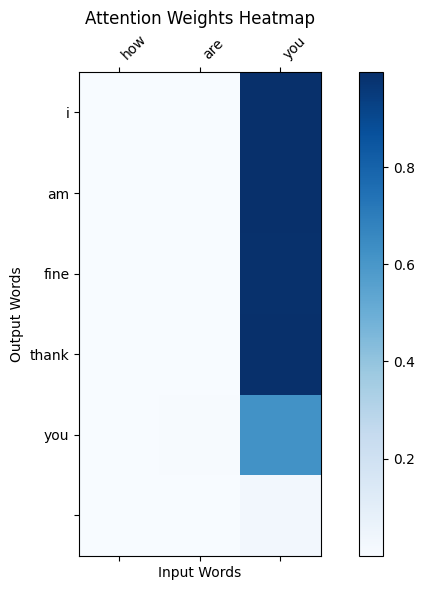

In [ ]:
# ─── CELL 17: Attention Heatmap for One Example ──────────────────────────────
user_input = "how are you"
response, input_words, attn_weights = generate_response(user_input)
output_words = response.split()

print(f"Input:  {user_input}")
print(f"Output: {response}")

plot_attention(input_words, output_words, attn_weights)
# The heatmap shows: when generating "fine", attention is heavy on "you" in the input